<a href="https://colab.research.google.com/github/asomanibernard191-arch/Syntecxhub_Flower_Classification/blob/main/Syntecxhub_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Downloading NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Loading SMS Spam Collection dataset directly from URL
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Encode labels: 'ham' -> 0, 'spam' -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Cleaning text function (lowercasing & removing punctuation/special chars)
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
  tokens = [word for word in text.split() if word not in stop_words]
  return ' '.join(tokens)
df['clean_message'] = df['message'].apply(clean_text)

# Inspect cleaned data
print(df[['label', 'clean_message']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


  label                                      clean_message
0   ham  go jurong point crazy available bugis n great ...
1   ham                            ok lar joking wif u oni
2  spam  free entry 2 wkly comp win fa cup final tkts 2...
3   ham                u dun say early hor u c already say
4   ham        nah dont think goes usf lives around though


Model Accuracy: 97.85%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



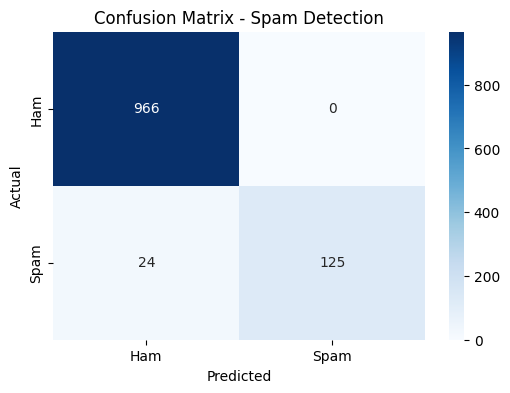

Model and vectorizer saved successfully!


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Splitting into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(df['clean_message'], df['label_num'], test_size=0.2, random_state=42)

# Vectorizing text using TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Training Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Printing accuracy and classification report (Precision, Recall, F1)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Spam Detection')
plt.show()
# Saving the vectorizer and model pipeline to disk
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(model, 'spam_model.pkl')
print("Model and vectorizer saved successfully!")

In [12]:
# Custom predictor function
def predict_sms(message):
  cleaned = clean_text(message)
  vectorized = tfidf.transform([cleaned])
  prediction = model.predict(vectorized)[0]
  return "SPAM 🚨" if prediction == 1 else "HAM (Legit) ✅"

# Test samples
sample_1 = "Congratulations! You've won a $1,000 gift card. Claim now at link.com"
sample_2 = "Hey, Asomani, are we still meeting for group study at the library today?"

# Displaying full context
def check_and_print(label, text):
  result = predict_sms(text)
  print(f"{label}: \"{text}\"\nPrediction: {result}\n")

check_and_print("Sample 1", sample_1)
check_and_print("Sample 2", sample_2)

Sample 1: "Congratulations! You've won a $1,000 gift card. Claim now at link.com"
Prediction: SPAM 🚨

Sample 2: "Hey, Asomani, are we still meeting for group study at the library today?"
Prediction: HAM (Legit) ✅

